# NWPU VHR-10 Dataset Audit

This notebook validates the original NWPU VHR-10 dataset before conversion or model training.

## Objectives

- Confirm the dataset directory structure
- Inventory images and annotation files
- Check image readability and dimensions
- Inspect the annotation format
- Match images with annotations
- Validate bounding boxes and class IDs
- Measure class distribution
- Visualize annotated samples
- Produce a final audit summary

The contents of `shared_resources/datasets/raw/` are treated as read-only.

In [2]:
# !pip install pandas matplotlib pillow pyyaml


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image

pd.set_option("display.max_colwidth", 120)

In [2]:
import sys

PROJECT_ROOT = Path.cwd().resolve()

# Notebook is running from repository/notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\HiWi\Desktop\Terril\01_nextcloud\Germany\DATA SCIENCE\01 SEMESTERS\06\01 Deep Learning in Remote Sensing\07 Final Project\retrieval-grounded-remote-sensing


In [ ]:


from src.utils.archive import extract_zip
from src.data.config import load_dataset_config
from src.utils.paths import find_project_root

PROJECT_ROOT = find_project_root()
config = load_dataset_config("nwpu_vhr10", PROJECT_ROOT)

dataset = config["dataset"]
archive_path = (PROJECT_ROOT / Path(dataset["archive"])).resolve()
raw_dir = (PROJECT_ROOT / Path(dataset["path"])).resolve()

extract_zip(
    archive_path=archive_path,
    destination=raw_dir,
    overwrite=False,
)

files = sorted(path for path in raw_dir.rglob("*") if path.is_file())

print(f"Extracted to: {raw_dir}")
print(f"Total files: {len(files)}\n")


Extracted to: C:\Users\HiWi\Desktop\Terril\01_nextcloud\Germany\DATA SCIENCE\01 SEMESTERS\06\01 Deep Learning in Remote Sensing\07 Final Project\retrieval-grounded-remote-sensing\shared_resources\datasets\raw
Total files: 1451

NWPU VHR-10 dataset\ground truth\001.txt
NWPU VHR-10 dataset\ground truth\002.txt
NWPU VHR-10 dataset\ground truth\003.txt
NWPU VHR-10 dataset\ground truth\004.txt
NWPU VHR-10 dataset\ground truth\005.txt
NWPU VHR-10 dataset\ground truth\006.txt
NWPU VHR-10 dataset\ground truth\007.txt
NWPU VHR-10 dataset\ground truth\008.txt
NWPU VHR-10 dataset\ground truth\009.txt
NWPU VHR-10 dataset\ground truth\010.txt
NWPU VHR-10 dataset\ground truth\011.txt
NWPU VHR-10 dataset\ground truth\012.txt
NWPU VHR-10 dataset\ground truth\013.txt
NWPU VHR-10 dataset\ground truth\014.txt
NWPU VHR-10 dataset\ground truth\015.txt
NWPU VHR-10 dataset\ground truth\016.txt
NWPU VHR-10 dataset\ground truth\017.txt
NWPU VHR-10 dataset\ground truth\018.txt
NWPU VHR-10 dataset\ground truth\0

In [ ]:
from collections import Counter

dataset = config["dataset"]
raw_dir = (PROJECT_ROOT / Path(dataset["path"])).resolve()

files = sorted(path for path in raw_dir.rglob("*") if path.is_file())

extension_counts = Counter(
    path.suffix.lower() or "[no extension]"
    for path in files
)

print("Raw dataset:", raw_dir)
print("Total files:", len(files))
print("File types:", dict(extension_counts))

print("\nFirst 40 files:")
for path in files[:40]:
    print(path.relative_to(raw_dir))

Raw dataset: C:\Users\HiWi\Desktop\Terril\01_nextcloud\Germany\DATA SCIENCE\01 SEMESTERS\06\01 Deep Learning in Remote Sensing\07 Final Project\retrieval-grounded-remote-sensing\shared_resources\datasets\raw
Total files: 1451
File types: {'.txt': 651, '.jpg': 800}

First 40 files:
NWPU VHR-10 dataset\ground truth\001.txt
NWPU VHR-10 dataset\ground truth\002.txt
NWPU VHR-10 dataset\ground truth\003.txt
NWPU VHR-10 dataset\ground truth\004.txt
NWPU VHR-10 dataset\ground truth\005.txt
NWPU VHR-10 dataset\ground truth\006.txt
NWPU VHR-10 dataset\ground truth\007.txt
NWPU VHR-10 dataset\ground truth\008.txt
NWPU VHR-10 dataset\ground truth\009.txt
NWPU VHR-10 dataset\ground truth\010.txt
NWPU VHR-10 dataset\ground truth\011.txt
NWPU VHR-10 dataset\ground truth\012.txt
NWPU VHR-10 dataset\ground truth\013.txt
NWPU VHR-10 dataset\ground truth\014.txt
NWPU VHR-10 dataset\ground truth\015.txt
NWPU VHR-10 dataset\ground truth\016.txt
NWPU VHR-10 dataset\ground truth\017.txt
NWPU VHR-10 dataset\g

In [19]:
image_files = sorted(raw_dir.rglob("*.jpg"))
txt_files = sorted(raw_dir.rglob("*.txt"))

numeric_annotations = [
    path for path in txt_files
    if path.stem.isdigit()
]

other_txt_files = [
    path for path in txt_files
    if not path.stem.isdigit()
]

print("Images:", len(image_files))
print("Numeric annotations:", len(numeric_annotations))
print("Other text files:", len(other_txt_files))

print("\nOther text files:")
for path in other_txt_files:
    print(path.relative_to(raw_dir))

print("\nFirst annotation:")
sample = numeric_annotations[0]
print("File:", sample.relative_to(raw_dir))
print(sample.read_text(encoding="utf-8", errors="replace"))

Images: 800
Numeric annotations: 650
Other text files: 1

Other text files:
NWPU VHR-10 dataset\readme.txt

First annotation:
File: NWPU VHR-10 dataset\ground truth\001.txt
(563,478),(630,573),1 



In [23]:
from src.data.parsers.nwpu import parse_nwpu_annotation

boxes = parse_nwpu_annotation(numeric_annotations[0])

print(f"Objects: {len(boxes)}")
print(boxes)

Objects: 1
[{'xmin': 563, 'ymin': 478, 'xmax': 630, 'ymax': 573, 'class_id': 1}]


In [26]:
from collections import Counter
from PIL import Image

from src.data.parsers.nwpu import parse_nwpu_annotation

image_by_stem = {path.stem: path for path in image_files}

class_counts = Counter()
issues = []
total_objects = 0
CLASS_NAMES = config["classes"]    

for annotation_path in numeric_annotations:
    stem = annotation_path.stem
    image_path = image_by_stem.get(stem)

    if image_path is None:
        issues.append((stem, "Missing matching image"))
        continue

    try:
        boxes = parse_nwpu_annotation(annotation_path)
    except ValueError as error:
        issues.append((stem, str(error)))
        continue

    with Image.open(image_path) as image:
        width, height = image.size

    for box_number, box in enumerate(boxes, start=1):
        total_objects += 1
        class_id = box["class_id"]
        class_counts[class_id] += 1

        if class_id not in CLASS_NAMES:
            issues.append(
                (stem, f"Box {box_number}: unknown class {class_id}")
            )

        if box["xmin"] >= box["xmax"] or box["ymin"] >= box["ymax"]:
            issues.append(
                (stem, f"Box {box_number}: invalid coordinates {box}")
            )

        if not (
            0 <= box["xmin"] < width
            and 0 <= box["xmax"] <= width
            and 0 <= box["ymin"] < height
            and 0 <= box["ymax"] <= height
        ):
            issues.append(
                (
                    stem,
                    f"Box {box_number}: outside {width}x{height} image",
                )
            )

print("Annotation files checked:", len(numeric_annotations))
print("Total objects:", total_objects)
print("Class distribution:")

for class_id in sorted(CLASS_NAMES):
    print(
        f"{class_id:>2} {CLASS_NAMES[class_id]:<20} "
        f"{class_counts[class_id]}"
    )

print("\nIssues found:", len(issues))

for issue in issues[:20]:
    print(issue)

Annotation files checked: 650
Total objects: 3896
Class distribution:
 1 airplane             757
 2 ship                 302
 3 storage_tank         655
 4 baseball_diamond     390
 5 tennis_court         524
 6 basketball_court     159
 7 ground_track_field   163
 8 harbor               224
 9 bridge               124
10 vehicle              598

Issues found: 0


In [27]:
image_stems = {path.stem for path in image_files}
annotation_stems = {path.stem for path in numeric_annotations}

background_images = sorted(image_stems - annotation_stems)
orphan_annotations = sorted(annotation_stems - image_stems)

print("Total images:", len(image_stems))
print("Annotated images:", len(image_stems & annotation_stems))
print("Background images:", len(background_images))
print("Annotations without images:", len(orphan_annotations))

print("\nFirst 20 background image IDs:")
print(background_images[:20])

if orphan_annotations:
    print("\nOrphan annotation IDs:")
    print(orphan_annotations)

Total images: 650
Annotated images: 650
Background images: 0
Annotations without images: 0

First 20 background image IDs:
[]


In [29]:
positive_images = sorted(
    path for path in image_files
    if path.parent.name.lower() == "positive image set"
)

background_images = sorted(
    path for path in image_files
    if path.parent.name.lower() == "negative image set"
)

positive_by_stem = {path.stem: path for path in positive_images}
annotation_stems = {path.stem for path in numeric_annotations}

missing_annotations = sorted(
    set(positive_by_stem) - annotation_stems
)
orphan_annotations = sorted(
    annotation_stems - set(positive_by_stem)
)

print("Total images:", len(image_files))
print("Positive images:", len(positive_images))
print("Background images:", len(background_images))
print("Annotations:", len(numeric_annotations))
print("Positive images without annotations:", len(missing_annotations))
print("Annotations without positive images:", len(orphan_annotations))

Total images: 800
Positive images: 650
Background images: 150
Annotations: 650
Positive images without annotations: 0
Annotations without positive images: 0


In [33]:
for i in axes.flat:
    print(i)

Axes(0.009375,0.567915;0.310574x0.326665)
Axes(0.344713,0.53865;0.310574x0.385196)
Axes(0.680051,0.580981;0.310574x0.300532)
Axes(0.009375,0.119162;0.310574x0.299181)
Axes(0.344713,0.096664;0.310574x0.344177)
Axes(0.680051,0.109364;0.310574x0.318778)


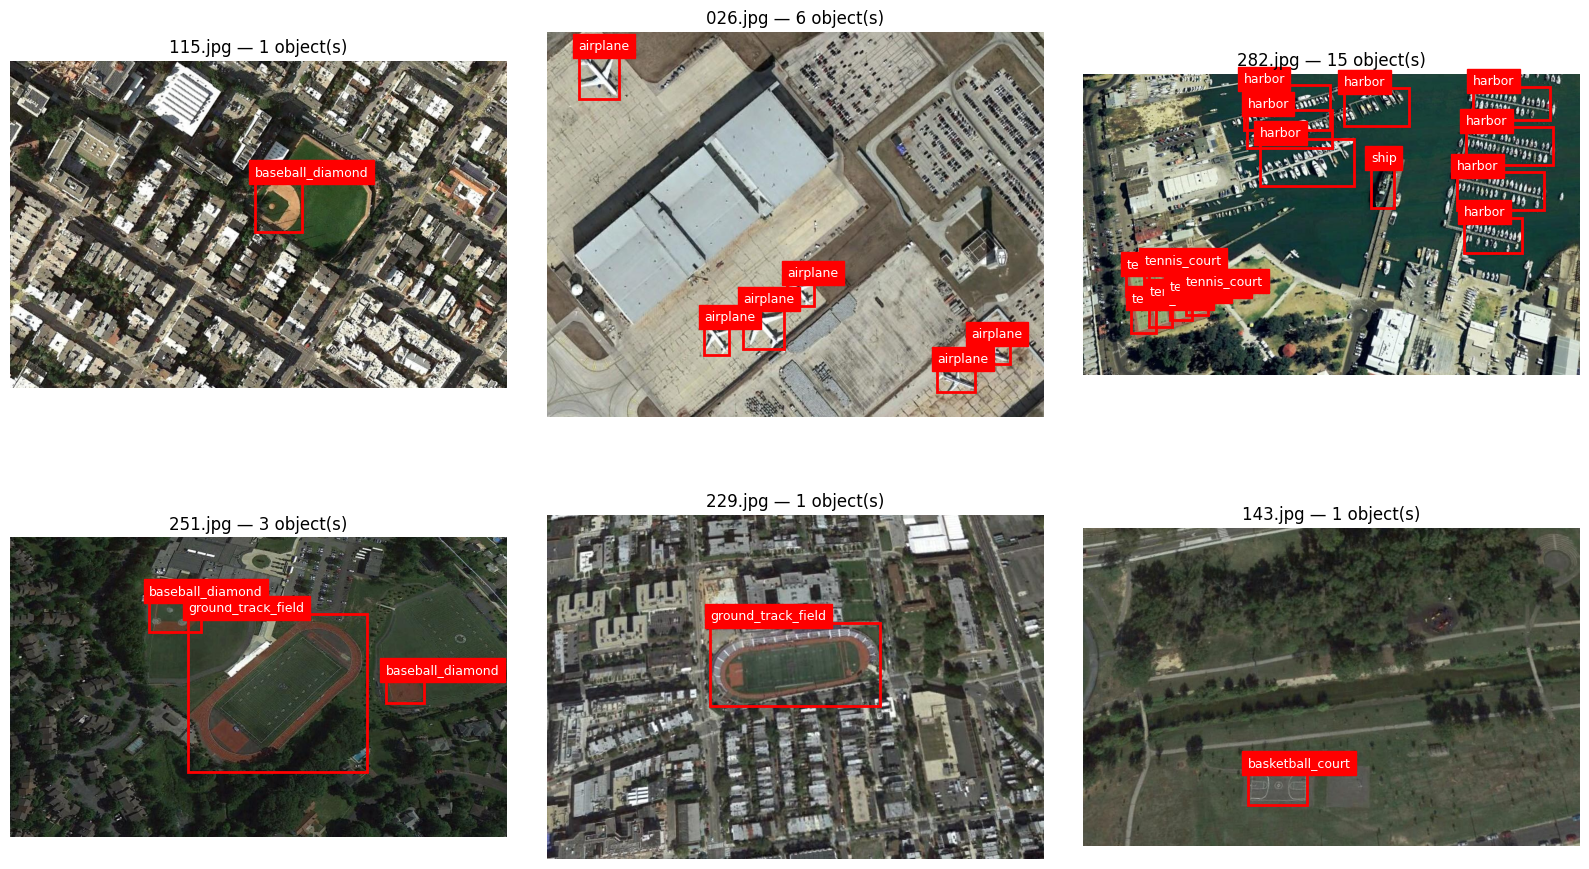

In [30]:
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

from src.data.parsers.nwpu import parse_nwpu_annotation

random.seed(42)
samples = random.sample(positive_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, image_path in zip(axes.flat, samples):
    annotation_path = next(
        path for path in numeric_annotations
        if path.stem == image_path.stem
    )

    image = Image.open(image_path).convert("RGB")
    boxes = parse_nwpu_annotation(annotation_path)

    ax.imshow(image)

    for box in boxes:
        xmin, ymin = box["xmin"], box["ymin"]
        width = box["xmax"] - xmin
        height = box["ymax"] - ymin
        class_id = box["class_id"]

        ax.add_patch(
            Rectangle(
                (xmin, ymin),
                width,
                height,
                fill=False,
                edgecolor="red",
                linewidth=2,
            )
        )

        ax.text(
            xmin,
            max(0, ymin - 5),
            CLASS_NAMES[class_id],
            color="white",
            fontsize=9,
            backgroundcolor="red",
        )

    ax.set_title(f"{image_path.name} — {len(boxes)} object(s)")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
from collections import Counter, defaultdict
import hashlib

hash_to_images = defaultdict(list)

for image_path in image_files:
    file_hash = hashlib.sha256(image_path.read_bytes()).hexdigest()
    hash_to_images[file_hash].append(image_path)

duplicate_groups = [
    paths for paths in hash_to_images.values()
    if len(paths) > 1
]

print("Images checked:", len(image_files))
print("Unique image contents:", len(hash_to_images))
print("Duplicate groups:", len(duplicate_groups))
print(
    "Extra duplicate copies:",
    sum(len(group) - 1 for group in duplicate_groups),
)

for group_number, group in enumerate(duplicate_groups[:20], start=1):
    print(f"\nDuplicate group {group_number}:")
    for path in group:
        print(" ", path.relative_to(raw_dir))

Images checked: 800
Unique image contents: 800
Duplicate groups: 0
Extra duplicate copies: 0


In [35]:
hash_to_images

defaultdict(list,
            {'f550426fa9326c141f4f749b776c63862446ffa291ce7d11453149ff015166c5': [WindowsPath('C:/Users/HiWi/Desktop/Terril/01_nextcloud/Germany/DATA SCIENCE/01 SEMESTERS/06/01 Deep Learning in Remote Sensing/07 Final Project/retrieval-grounded-remote-sensing/shared_resources/datasets/raw/NWPU VHR-10 dataset/negative image set/001.jpg')],
             'bfca2b87ede52315cb0674bcab66511deb0f80bdb0a51d7639c2259b992d669a': [WindowsPath('C:/Users/HiWi/Desktop/Terril/01_nextcloud/Germany/DATA SCIENCE/01 SEMESTERS/06/01 Deep Learning in Remote Sensing/07 Final Project/retrieval-grounded-remote-sensing/shared_resources/datasets/raw/NWPU VHR-10 dataset/negative image set/002.jpg')],
             'a7a8446b0e607db3281de81d9ab4145ac95de3ffa6a76c6a0fae7a2035233734': [WindowsPath('C:/Users/HiWi/Desktop/Terril/01_nextcloud/Germany/DATA SCIENCE/01 SEMESTERS/06/01 Deep Learning in Remote Sensing/07 Final Project/retrieval-grounded-remote-sensing/shared_resources/datasets/raw/NWPU VHR-1

In [36]:
from collections import Counter

from PIL import Image, UnidentifiedImageError

image_records = []
image_issues = []

for image_path in image_files:
    try:
        with Image.open(image_path) as image:
            image.verify()  # Check file integrity

        with Image.open(image_path) as image:
            width, height = image.size
            mode = image.mode

        image_records.append({
            "path": image_path.relative_to(raw_dir),
            "width": width,
            "height": height,
            "mode": mode,
        })

        if width <= 0 or height <= 0:
            image_issues.append(
                (image_path.relative_to(raw_dir), "Invalid dimensions")
            )

    except (UnidentifiedImageError, OSError, ValueError) as error:
        image_issues.append(
            (image_path.relative_to(raw_dir), str(error))
        )

dimension_counts = Counter(
    (record["width"], record["height"])
    for record in image_records
)

mode_counts = Counter(
    record["mode"]
    for record in image_records
)

print("Images checked:", len(image_files))
print("Readable images:", len(image_records))
print("Unreadable or invalid images:", len(image_issues))

print("\nImage dimensions:")
for dimensions, count in dimension_counts.most_common():
    print(f"{dimensions[0]} × {dimensions[1]}: {count}")

print("\nImage modes:", dict(mode_counts))

if image_issues:
    print("\nIssues:")
    for path, issue in image_issues[:20]:
        print(path, "—", issue)

Images checked: 800
Readable images: 800
Unreadable or invalid images: 0

Image dimensions:
979 × 751: 2
831 × 540: 2
968 × 776: 2
964 × 761: 2
974 × 749: 2
902 × 611: 2
1066 × 588: 1
885 × 541: 1
973 × 564: 1
876 × 601: 1
877 × 520: 1
1032 × 592: 1
945 × 585: 1
1104 × 550: 1
987 × 558: 1
876 × 565: 1
849 × 587: 1
1027 × 552: 1
789 × 584: 1
996 × 567: 1
851 × 567: 1
693 × 543: 1
894 × 558: 1
934 × 561: 1
889 × 578: 1
925 × 558: 1
826 × 571: 1
818 × 536: 1
930 × 574: 1
990 × 549: 1
975 × 564: 1
908 × 534: 1
903 × 591: 1
902 × 585: 1
1043 × 565: 1
906 × 572: 1
852 × 569: 1
988 × 571: 1
1052 × 578: 1
962 × 561: 1
831 × 521: 1
931 × 572: 1
998 × 583: 1
945 × 561: 1
891 × 552: 1
814 × 552: 1
1018 × 562: 1
986 × 553: 1
1035 × 560: 1
1083 × 544: 1
1132 × 560: 1
886 × 546: 1
1121 × 551: 1
1109 × 559: 1
1119 × 553: 1
1000 × 547: 1
947 × 544: 1
1131 × 552: 1
960 × 563: 1
998 × 535: 1
952 × 566: 1
997 × 555: 1
954 × 545: 1
1050 × 554: 1
948 × 575: 1
920 × 582: 1
934 × 534: 1
920 × 556: 1
1047 × 5

In [37]:
from collections import Counter

from PIL import Image

from src.data.parsers.nwpu import parse_nwpu_annotation

annotation_by_stem = {
    path.stem: path
    for path in numeric_annotations
}

class_counts = Counter()
objects_per_image = Counter()
box_issues = []
box_records = []

for image_path in positive_images:
    annotation_path = annotation_by_stem[image_path.stem]
    boxes = parse_nwpu_annotation(annotation_path)

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    objects_per_image[len(boxes)] += 1

    for box_number, box in enumerate(boxes, start=1):
        xmin, ymin = box["xmin"], box["ymin"]
        xmax, ymax = box["xmax"], box["ymax"]
        class_id = box["class_id"]

        box_width = xmax - xmin
        box_height = ymax - ymin
        relative_area = (
            box_width * box_height
        ) / (
            image_width * image_height
        )

        class_counts[class_id] += 1

        box_records.append({
            "image": image_path.name,
            "class_id": class_id,
            "width": box_width,
            "height": box_height,
            "relative_area": relative_area,
        })

        if box_width <= 0 or box_height <= 0:
            box_issues.append(
                (image_path.name, box_number, "Invalid box size")
            )

        if not (
            0 <= xmin < xmax <= image_width
            and 0 <= ymin < ymax <= image_height
        ):
            box_issues.append(
                (image_path.name, box_number, "Box outside image")
            )

print("Positive images checked:", len(positive_images))
print("Total objects:", len(box_records))
print("Bounding-box issues:", len(box_issues))

print("\nClass distribution:")
for class_id in sorted(CLASS_NAMES):
    print(
        f"{class_id:>2} "
        f"{CLASS_NAMES[class_id]:<20} "
        f"{class_counts[class_id]}"
    )

print("\nObjects per image:")
for object_count, image_count in sorted(objects_per_image.items()):
    print(f"{object_count:>2} object(s): {image_count} images")

areas = [record["relative_area"] for record in box_records]

print("\nRelative bounding-box area:")
print(f"Minimum: {min(areas):.6f}")
print(f"Maximum: {max(areas):.6f}")
print(f"Average: {sum(areas) / len(areas):.6f}")

if box_issues:
    print("\nFirst issues:")
    for issue in box_issues[:20]:
        print(issue)

Positive images checked: 650
Total objects: 3896
Bounding-box issues: 0

Class distribution:
 1 airplane             757
 2 ship                 302
 3 storage_tank         655
 4 baseball_diamond     390
 5 tennis_court         524
 6 basketball_court     159
 7 ground_track_field   163
 8 harbor               224
 9 bridge               124
10 vehicle              598

Objects per image:
 1 object(s): 102 images
 2 object(s): 119 images
 3 object(s): 86 images
 4 object(s): 62 images
 5 object(s): 55 images
 6 object(s): 39 images
 7 object(s): 28 images
 8 object(s): 30 images
 9 object(s): 26 images
10 object(s): 19 images
11 object(s): 8 images
12 object(s): 13 images
13 object(s): 10 images
14 object(s): 6 images
15 object(s): 5 images
16 object(s): 4 images
17 object(s): 3 images
18 object(s): 6 images
19 object(s): 3 images
20 object(s): 3 images
21 object(s): 3 images
22 object(s): 1 images
23 object(s): 2 images
24 object(s): 1 images
25 object(s): 1 images
26 object(s): 2 im

In [39]:
box_records

[{'image': '001.jpg',
  'class_id': 1,
  'width': 67,
  'height': 95,
  'relative_area': 0.008222834287604126},
 {'image': '002.jpg',
  'class_id': 1,
  'width': 60,
  'height': 48,
  'relative_area': 0.0037612642026903487},
 {'image': '002.jpg',
  'class_id': 1,
  'width': 61,
  'height': 64,
  'relative_area': 0.0050986025858691395},
 {'image': '002.jpg',
  'class_id': 1,
  'width': 63,
  'height': 67,
  'relative_area': 0.005512602847068043},
 {'image': '002.jpg',
  'class_id': 1,
  'width': 38,
  'height': 46,
  'relative_area': 0.00228287841191067},
 {'image': '002.jpg',
  'class_id': 1,
  'width': 88,
  'height': 101,
  'relative_area': 0.011607679247747159},
 {'image': '002.jpg',
  'class_id': 1,
  'width': 79,
  'height': 102,
  'relative_area': 0.010523703800444038},
 {'image': '002.jpg',
  'class_id': 1,
  'width': 88,
  'height': 110,
  'relative_area': 0.012642026903487005},
 {'image': '003.jpg',
  'class_id': 1,
  'width': 70,
  'height': 63,
  'relative_area': 0.006177621

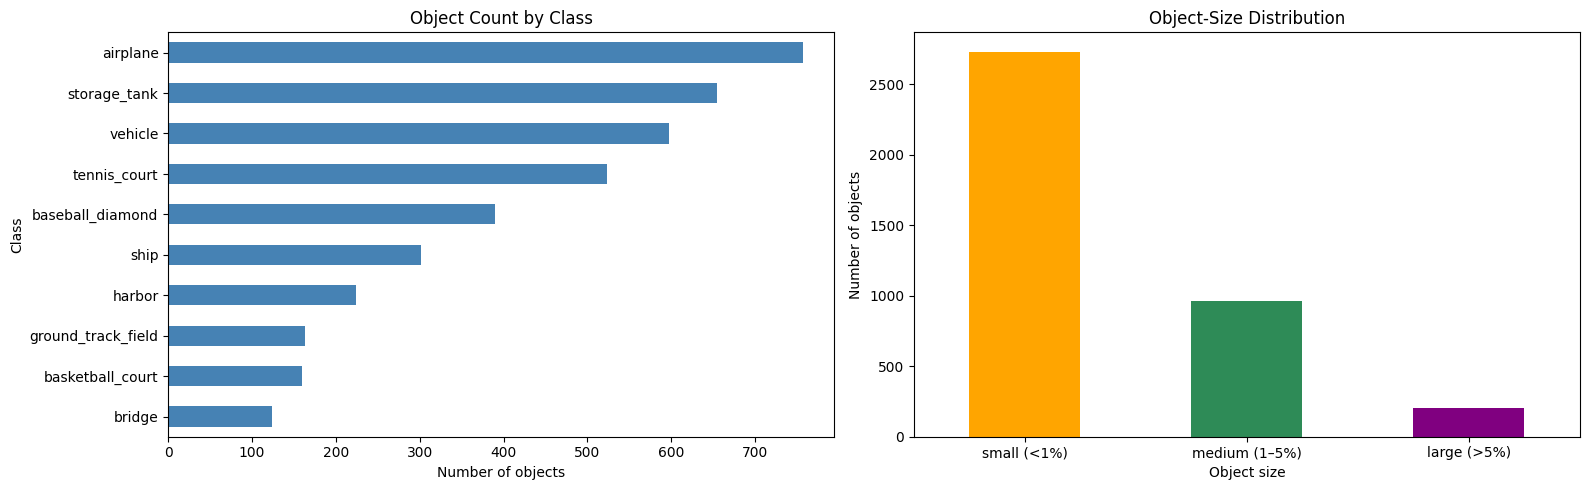

Class distribution:
class_name
airplane              757
storage_tank          655
vehicle               598
tennis_court          524
baseball_diamond      390
ship                  302
harbor                224
ground_track_field    163
basketball_court      159
bridge                124
Name: count, dtype: int64

Object-size distribution:
size
small (<1%)      2732
medium (1–5%)     961
large (>5%)       203
Name: count, dtype: int64

Class imbalance ratio: 6.10:1


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

boxes_df = pd.DataFrame(box_records)
boxes_df["class_name"] = boxes_df["class_id"].map(CLASS_NAMES)

# Object-size categories based on percentage of image area
boxes_df["size"] = pd.cut(
    boxes_df["relative_area"],
    bins=[0, 0.01, 0.05, 1],
    labels=["small (<1%)", "medium (1–5%)", "large (>5%)"],
    include_lowest=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

class_distribution = (
    boxes_df["class_name"]
    .value_counts()
    .sort_values()
)

class_distribution.plot.barh(
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Object Count by Class")
axes[0].set_xlabel("Number of objects")
axes[0].set_ylabel("Class")

size_distribution = (
    boxes_df["size"]
    .value_counts()
    .reindex(["small (<1%)", "medium (1–5%)", "large (>5%)"])
)

size_distribution.plot.bar(
    ax=axes[1],
    color=["orange", "seagreen", "purple"],
)
axes[1].set_title("Object-Size Distribution")
axes[1].set_xlabel("Object size")
axes[1].set_ylabel("Number of objects")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Class distribution:")
print(class_distribution.sort_values(ascending=False))

print("\nObject-size distribution:")
print(size_distribution)

imbalance_ratio = (
    class_distribution.max() / class_distribution.min()
)

print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")

In [4]:
from pathlib import Path

from src.data.adapters.nwpu import discover_nwpu_items
from src.data.audit import audit_dataset
from src.data.parsers.nwpu import parse_nwpu_annotation
from src.data.reporting import (
    boxes_dataframe,
    issues_dataframe,
    print_audit_summary,
)
from src.data.config import load_dataset_config

config = load_dataset_config("nwpu_vhr10", PROJECT_ROOT)
# Use your existing PROJECT_ROOT and config variables
raw_dir = (
    PROJECT_ROOT / Path(config["dataset"]["path"])
).resolve()

CLASS_NAMES = {
    1: "airplane",
    2: "ship",
    3: "storage tank",
    4: "baseball diamond",
    5: "tennis court",
    6: "basketball court",
    7: "ground track field",
    8: "harbor",
    9: "bridge",
    10: "vehicle",
}

items = discover_nwpu_items(raw_dir)

report = audit_dataset(
    items=items,
    parser=parse_nwpu_annotation,
    valid_class_ids=set(CLASS_NAMES),
)

print_audit_summary(report)

boxes_df = boxes_dataframe(report)
issues_df = issues_dataframe(report)

display(boxes_df.head())
display(issues_df)

DATASET AUDIT
----------------------------------------
Total images: 800
Positive images: 650
Background images: 150
Readable images: 800
Total objects: 3896
Issues: 0
Duplicate groups: 0

Class counts:
  1: 757
  2: 302
  3: 655
  4: 390
  5: 524
  6: 159
  7: 163
  8: 224
  9: 124
  10: 598

Object sizes:
  small: 2731
  medium: 962
  large: 203


,image,class_id,xmin,ymin,xmax,ymax,box_width,box_height,relative_area,size
0,001.jpg,1,563,478,630,573,67,95,0.008223,small
1,002.jpg,1,575,114,635,162,60,48,0.003761,small
2,002.jpg,1,72,305,133,369,61,64,0.005099,small
3,002.jpg,1,210,317,273,384,63,67,0.005513,small
4,002.jpg,1,306,374,344,420,38,46,0.002283,small


""


## Optional external test subset: HRRSD

HRRSD uses the same ten classes as NWPU VHR-10 plus three additional classes. The official images are distributed as RAR archives, so class-selective downloading is not available: this cell downloads and extracts them only in temporary Colab storage, then persists a deterministic, class-balanced subset below 1 GB. Change `TARGET_CLASSES` to select the classes needed for external testing.

In [8]:
import csv
import os
import random
import shutil
import subprocess
import sys
import tempfile
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path

TARGET_CLASSES = ("airplane", "ship", "storage tank", "bridge")
MAX_PERSISTED_BYTES = 950_000_000  # margin below the requested 1 GB
SEED = 42
HRRSD_DRIVE_FOLDER_ID = "1bffECWdpa0jg2Jnm7V0oCyFFh0N-EIkr"

shared_root = Path(os.environ["SHARED_RESOURCES_ROOT"]).resolve()
output_root = shared_root / "datasets" / "raw" / "HRRSD_external_subset_seed42"
if output_root.exists():
    raise FileExistsError(f"Subset already exists: {output_root}")

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "gdown>=5.1,<7", "kagglehub>=1,<2",
], check=True)
subprocess.run(["apt-get", "update", "-qq"], check=True)
subprocess.run(["apt-get", "install", "-y", "-qq", "p7zip-full"], check=True)
import gdown

work_root = Path(tempfile.mkdtemp(prefix="hrrsd_", dir="/content"))
download_root = work_root / "downloads"
extract_root = work_root / "extracted"
download_root.mkdir()
extract_root.mkdir()

metadata_root = work_root / "TGRS-HRRSD-Dataset"
subprocess.run([
    "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
    "--branch", "mstr-gthb",
    "https://github.com/CrazyStoneonRoad/TGRS-HRRSD-Dataset.git",
    str(metadata_root),
], check=True)
subprocess.run([
    "git", "-C", str(metadata_root), "sparse-checkout", "set",
    "OPT2017/Annotations",
], check=True)

print("Downloading official HRRSD archives to temporary Colab storage...")
downloaded = gdown.download_folder(
    id=HRRSD_DRIVE_FOLDER_ID,
    output=str(download_root),
    quiet=False,
    remaining_ok=True,
)
archive_suffixes = {".rar", ".zip", ".7z"}
downloaded_files = sorted(path for path in download_root.rglob("*") if path.is_file())
archives = [path for path in downloaded_files if path.suffix.lower() in archive_suffixes]
image_search_root = extract_root
if not archives:
    print("Official Drive link is unavailable; using the public Kaggle mirror...")
    import kagglehub
    mirror_root = Path(kagglehub.dataset_download(
        "haashaatif/tgrshrrsd-dataset",
        output_dir=str(work_root / "kaggle"),
    ))
    mirror_files = sorted(path for path in mirror_root.rglob("*") if path.is_file())
    archives = [path for path in mirror_files if path.suffix.lower() in archive_suffixes]
    if not archives:
        image_search_root = mirror_root
for archive in archives:
    subprocess.run(["7z", "x", "-y", f"-o{extract_root}", str(archive)], check=True)

images = {
    path.stem: path
    for path in image_search_root.rglob("*")
    if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
}
annotations = {path.stem: path for path in metadata_root.rglob("*.xml")}
records = {}
by_class = defaultdict(list)
for stem in sorted(images.keys() & annotations.keys()):
    names = tuple(sorted({
        node.text.strip().lower()
        for node in ET.parse(annotations[stem]).findall(".//object/name")
        if node.text
    }))
    matched = set(names) & set(TARGET_CLASSES)
    if matched and set(names) <= set(TARGET_CLASSES):
        records[stem] = names
        for class_name in matched:
            by_class[class_name].append(stem)

rng = random.Random(SEED)
for stems in by_class.values():
    rng.shuffle(stems)
selected, selected_set, saved_bytes = [], set(), 0
while True:
    added = False
    for class_name in TARGET_CLASSES:
        while by_class[class_name] and by_class[class_name][-1] in selected_set:
            by_class[class_name].pop()
        if not by_class[class_name]:
            continue
        stem = by_class[class_name].pop()
        pair_bytes = images[stem].stat().st_size + annotations[stem].stat().st_size
        if saved_bytes + pair_bytes > MAX_PERSISTED_BYTES:
            continue
        selected.append(stem)
        selected_set.add(stem)
        saved_bytes += pair_bytes
        added = True
    if not added:
        break

image_output = output_root / "JPEGImages"
annotation_output = output_root / "Annotations"
image_output.mkdir(parents=True)
annotation_output.mkdir()
with (output_root / "subset_manifest.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["image_id", "classes", "image_bytes"])
    for stem in selected:
        shutil.copy2(images[stem], image_output / images[stem].name)
        shutil.copy2(annotations[stem], annotation_output / annotations[stem].name)
        writer.writerow([stem, "|".join(records[stem]), images[stem].stat().st_size])

shutil.rmtree(work_root)
class_counts = Counter(name for stem in selected for name in records[stem])
print(f"Saved {len(selected)} images ({saved_bytes / 1_000_000:.1f} MB): {output_root}")
print("Objects represented by image-level class presence:", dict(class_counts))

Retrieving folder contents
Failed to retrieve folder contents


Official Drive link is unavailable; using the public Kaggle mirror...


100%|██████████| 8.69G/8.69G [07:34<00:00, 20.5MB/s]  

Extracting files...


Saved 1913 images (950.0 MB): /content/drive/Othercomputers/My laptop/shared_resources/datasets/raw/HRRSD_external_subset_seed42
Objects represented by image-level class presence: {'airplane': 483, 'ship': 514, 'storage tank': 485, 'bridge': 503}
